# #4 Plot Ancestral Linkage

## Purpose

Plot ancestral linkage for germ layers, cell types, and cell subtypes

## Setup

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from devmap.config import get_paths, lineage_palette, set_theme
from devmap.linkage import get_mean_linkage
from devmap.plots import draw_marginal_strip, plot_linkage_heatmap
from devmap.utils import load_data, save_plot

set_theme()
base_path, plots_path, results_path = get_paths("fate")

## Load data

In [ ]:
tdata = load_data("umap")
cell_types = pd.read_csv(base_path / "data" / "cell_types.csv", index_col=0)
cell_types["name"] = cell_types.index + " " + cell_types["subtype_id"]
cell_type_info = cell_types.drop_duplicates("cell_type").set_index("cell_type")
subtype_to_name = cell_types["name"].to_dict()

## Stage germ layer linkage

In [ ]:
order = ["Epiblast", "Endoderm", "Mesoderm", "Ectoderm"]
for stage in ["E7.5","E8.0","E8.5","E9.0","E9.5"]:
    germ_layer_linkage = get_mean_linkage(results_path, "germ_layer_linkage", [f"{stage}-R1", f"{stage}-R2", f"{stage}-R3"])
    fig, ax = plt.subplots(figsize=(.6, .6), dpi=600)
    ax, order = plot_linkage_heatmap(germ_layer_linkage, ax = ax,symmetrize="mean", cmap="RdBu_r", order =order,
                        center=0, vmin=-1.5, vmax=1.5, scatter_size_range=(2, 10), var_vmax=0.2)
    save_plot(plots_path / f"{stage}_germ_layer_linkage.svg", fig)

## E9.5 cell type linkage

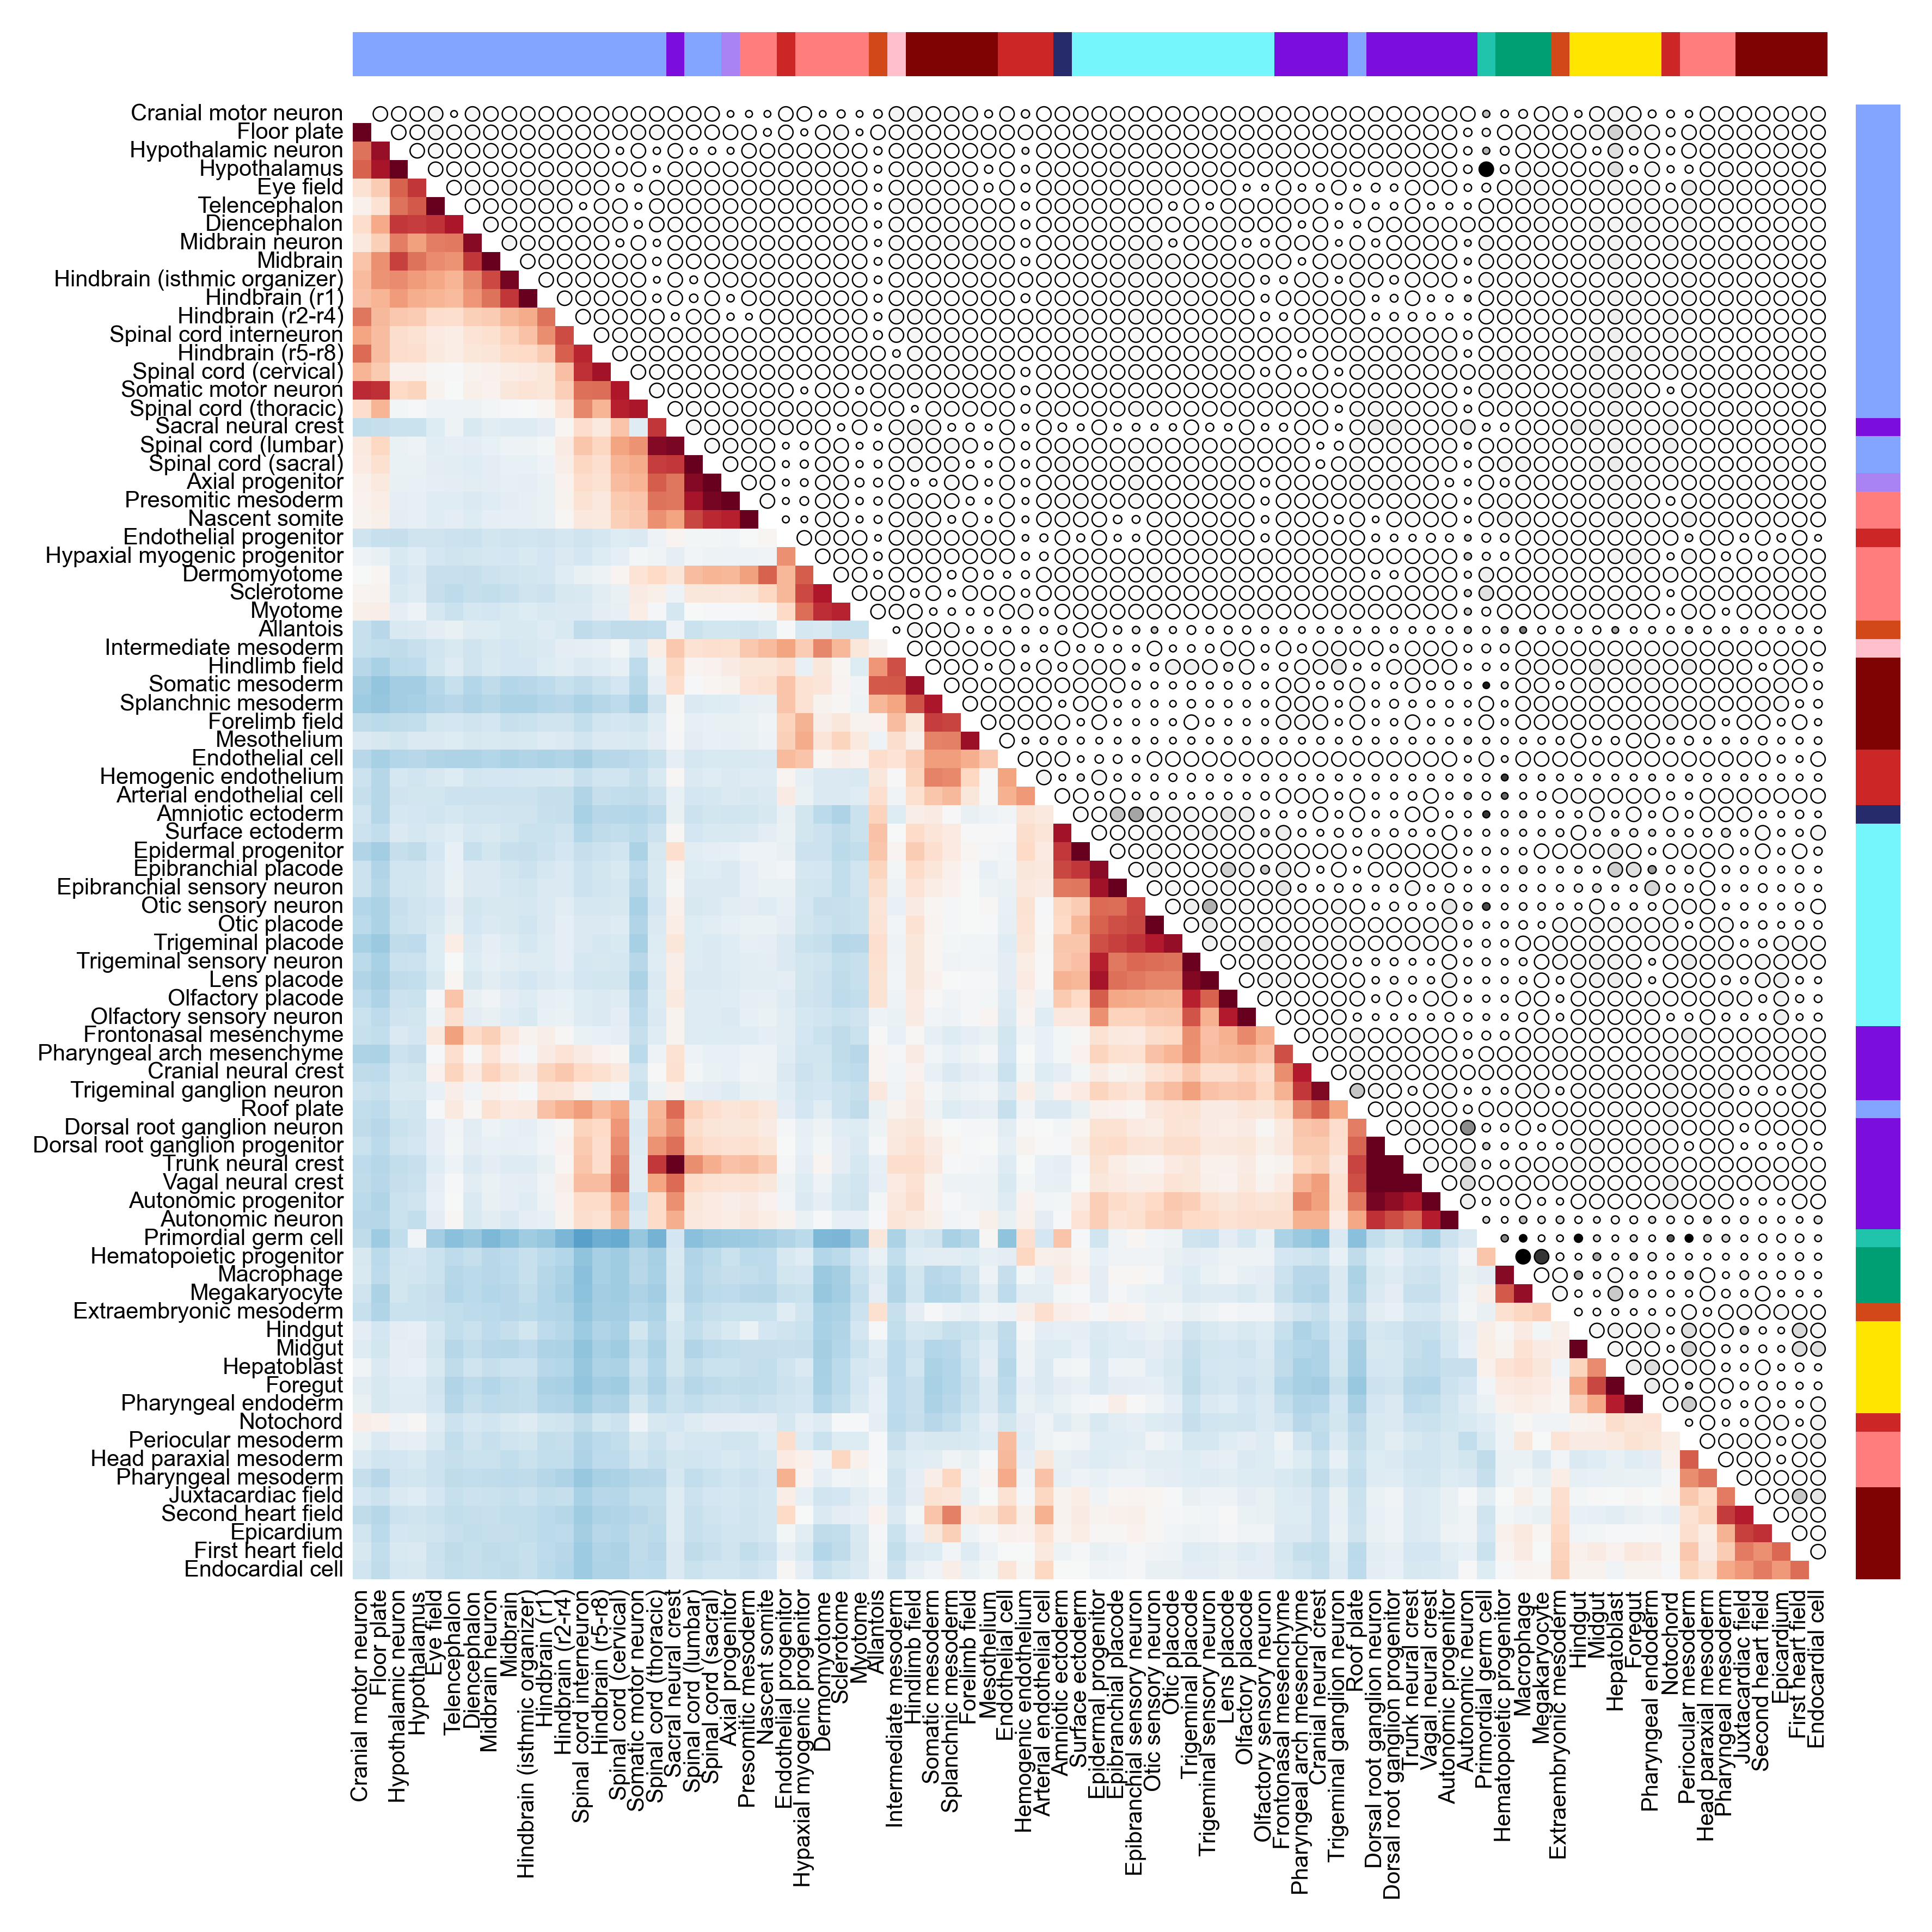

In [87]:
celltype_linkage = get_mean_linkage(results_path, "cell_type_linkage", ["E9.5-R1", "E9.5-R2", "E9.5-R3"])
fig = plt.figure(figsize=(5.8, 5.8), dpi=600, layout="constrained")
gs = fig.add_gridspec(
    2, 2,
    width_ratios=[1, 0.03],
    height_ratios=[0.03, 1],
    wspace=0.0,
    hspace=0.0,
)
ax_col = fig.add_subplot(gs[0, 0])  # top color strip 1
ax      = fig.add_subplot(gs[1, 0])  # heatmap
ax_row = fig.add_subplot(gs[1, 1])  # right color strip 1
ax, order = plot_linkage_heatmap(celltype_linkage, ax = ax, cmap="RdBu_r", order_method="average",
                     center=0, vmin=-1.5, vmax=1.5, scatter_size_range=(2, 10), var_vmax=0.2)
draw_marginal_strip(ax_col, cell_type_info["lineage"], lineage_palette, ordered_index=order)
draw_marginal_strip(ax_row, cell_type_info["lineage"], lineage_palette, ordered_index=order, orientation="row")

## E9.5 replicates

In [ ]:
for i in range(1,4):
    embryo = f"E9.5-R{i}"
    embryo_linkage = pd.read_csv(results_path / "cell_type_linkage" / f"{embryo}_linkage.csv", index_col=0)
    embryo_linkage["norm_value"] = embryo_linkage["value"] - embryo_linkage["permuted_value"]
    fig = plt.figure(figsize=(5.8, 5.8), dpi=600, layout="constrained")
    gs = fig.add_gridspec(
    2, 2,
    width_ratios=[1, 0.03],
    height_ratios=[0.03, 1],
    wspace=0.0,
    hspace=0.0,
    )
    ax_col = fig.add_subplot(gs[0, 0])  # top color strip 1
    ax      = fig.add_subplot(gs[1, 0])  # heatmap
    ax_row = fig.add_subplot(gs[1, 1])  # right color strip 1
    embryo_order = order.intersection(embryo_linkage["source"].unique())
    ax, _ = plot_linkage_heatmap(embryo_linkage, ax = ax,symmetrize="mean", cmap="RdBu_r", order = embryo_order,
                        center=0, vmin=-1.5, vmax=1.5, show_var = False, lower_diagonal_only = True)
    draw_marginal_strip(ax_col, cell_type_info["lineage"], lineage_palette, ordered_index=order)
    draw_marginal_strip(ax_row, cell_type_info["lineage"], lineage_palette, ordered_index=order, orientation="row")
    save_plot(plots_path / f"{embryo}_cell_type_linkage.svg", fig)

## Stage cell type linkage

In [ ]:
for stage in ["E7.5","E8.0","E8.5","E9.0","E9.5"]:
    type_linkage = get_mean_linkage(results_path, "cell_type_linkage", [f"{stage}-R1", f"{stage}-R2", f"{stage}-R3"])
    stage_types = type_linkage.groupby("source")["source_n"].first().loc[lambda x: x > 20].index
    type_linkage = type_linkage.query("source in @stage_types and target in @stage_types")
    n = len(stage_types)
    fig, ax = plt.subplots(figsize=(0.13*n + 2, 0.13*n + 2), dpi=600)
    ax, order = plot_linkage_heatmap(type_linkage, ax = ax,symmetrize=None, cmap="RdBu_r", order_method="average",
                        center=0, vmin=-1.5, vmax=1.5, scatter_size_range=(2, 10), var_vmax=0.2, show_var=False)
    type_linkage.to_csv(results_path / "mean_linkage" / f"{stage}_type_linkage.csv", index=False)
    order.to_frame().to_csv(results_path / "mean_linkage" / f"{stage}_type_order.csv", index=False, header=False)

## Stage subtype linkage

In [ ]:
for stage in ["E7.5","E8.0","E8.5","E9.0","E9.5"]:
    subtype_linkage = get_mean_linkage(results_path, "cell_subtype_linkage", [f"{stage}-R1", f"{stage}-R2", f"{stage}-R3"])
    stage_subtypes = subtype_linkage.groupby("source")["source_n"].first().loc[lambda x: x > 20].index
    subtype_linkage = subtype_linkage.query("source in @stage_subtypes and target in @stage_subtypes")
    subtype_linkage["source"] = subtype_linkage["source"].map(subtype_to_name)
    subtype_linkage["target"] = subtype_linkage["target"].map(subtype_to_name)
    n = len(stage_subtypes)
    fig, ax = plt.subplots(figsize=(0.13*n + 2, 0.13*n + 2), dpi=600)
    ax, order = plot_linkage_heatmap(subtype_linkage, ax = ax, cmap="RdBu_r", order_method="average",
                        center=0, vmin=-1.5, vmax=1.5, scatter_size_range=(2, 10), var_vmax=0.2, show_var=False)
    save_plot(plots_path / f"{stage}_subtype_linkage.svg", fig)
    subtype_linkage.to_csv(results_path / "mean_linkage" / f"{stage}_subtype_linkage.csv", index=False)
    order.to_frame().to_csv(results_path / "mean_linkage" / f"{stage}_subtype_order.csv", index=False, header=False)

## Cluster subtype linkage

In [16]:
use_subtypes = tdata.obs.query("stage == 'E9.5' & clone.notnull()")["cell_subtype"].value_counts()
use_subtypes = use_subtypes[use_subtypes > 20].index.tolist()
embryos = ["E8.5-R1","E8.5-R2","E8.5-R3","E9.0-R1","E9.0-R2","E9.0-R3","E9.5-R1","E9.5-R2","E9.5-R3","E10.0-R1"]
subtype_linkage = get_mean_linkage(results_path, "cell_subtype_linkage", embryos, weighted=True)

In [ ]:
for cluster in cell_types.cluster.unique():
    if cluster == "Early":
        continue
    cluster_subtypes = cell_types.query("cluster == @cluster & index in @use_subtypes").index
    n = len(cluster_subtypes)
    fig, ax = plt.subplots(figsize=(0.13*n + 2, 0.13*n + 2), dpi=600)
    cluster_linkage = subtype_linkage.query("source in @cluster_subtypes and target in @cluster_subtypes").copy()
    cluster_linkage["source"] = cluster_linkage["source"].map(subtype_to_name)
    cluster_linkage["target"] = cluster_linkage["target"].map(subtype_to_name)
    ax, order = plot_linkage_heatmap(cluster_linkage, ax = ax, cmap="RdBu_r", order_method="average",
                        center=0, vmin=-1.5, vmax=1.5, scatter_size_range=(2, 10), var_vmax=0.2, show_var=False)
    save_plot(plots_path / f"{cluster.replace(' ', '_')}_linkage.svg", fig)